**Problem 4b

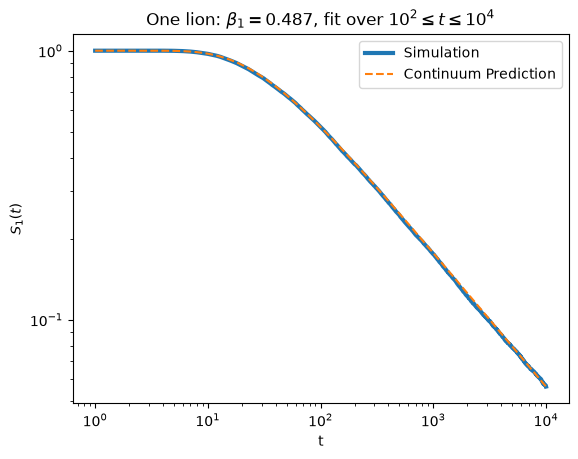

In [32]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.special import erf
import pandas as pd

#Set up the problem
r = 2 * (10 ** 4)
t = 10 ** 4
d_0 = 10

#create lambs and lions
lamb = np.zeros(r, dtype = int)
lion = np.full(r, d_0, dtype = int)

#tracking the lambs
alive = np.ones(r, dtype = bool)

#store emp probs for each t
s_1 = np.full(t + 1, np.nan)
s_1[0] = 1.0

#simulate
for i in range(1, t + 1):
    #Number of alive lambs
    n_alive = alive.sum()

    #take steps
    lamb[alive] += np.random.choice([-1, 1], size  = n_alive)
    lion[alive] += np.random.choice([-1, 1], size = n_alive)

    #which ones got caught?
    caught = alive & (lamb == lion)
    alive[caught] = False

    #calculate emp prob
    s_1[i] = alive.mean()

#making the plot
t_axis = np.arange(t + 1)
fit = (t_axis >= 10 ** 2) & (t_axis <= 10 ** 4) & (s_1 > 0) #s_1 > 0 so we dont take log(0)

#line fit, here beta should be the slope since ln(s_1) = -beta ln(t) + some constant
slope, intercept = np.polyfit(
    np.log(t_axis[fit]),
    np.log(s_1[fit]),
    1
)

beta = -slope

#plot
t_plot = t_axis[1:] #taking out 0 becuase of sqrt in denom later

continuum = erf(d_0 / (2 * np.sqrt(t_plot)))

plt.loglog(t_plot, s_1[1:], label = "Simulation", linewidth = 3)
plt.loglog(t_plot, continuum, "--",label = "Continuum Prediction")

plt.xlabel("t")
plt.ylabel(r"$S_1(t)$")
plt.title(rf"One lion: $\beta_1 = {beta:.3f}$, fit over $10^2 \leq t \leq 10^4$")
plt.legend()
plt.show()





**Problem 4c

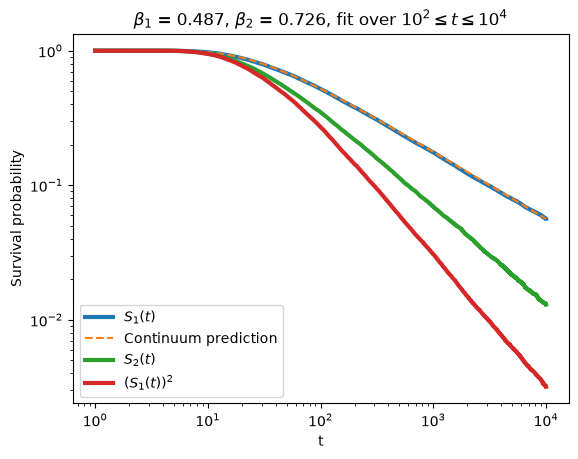

,t,S_2(t),(S_1(t))^2
0,100,0.34880,0.270348
1,1000,0.06925,0.030730
2,10000,0.01300,0.003187


In [34]:
#I am going to use the same stucture as my first sim
lamb_1 = np.zeros(r, dtype = int)

lion_1 = np.full(r, d_0, dtype = int)
lion_2 = np.full(r, d_0, dtype = int)

alive_1 = np.ones(r, dtype= bool)

s_2 = np.full(t + 1, np.nan)
s_2[0] = 1.0

#sim
for i in range(1, t + 1):
    n_alive = alive_1.sum()
    
    lamb_1[alive_1] += np.random.choice([-1, 1], size = n_alive)
    lion_1[alive_1] += np.random.choice([-1, 1], size = n_alive)
    lion_2[alive_1] += np.random.choice([-1, 1], size = n_alive)

    caught = alive_1 & ((lamb_1 == lion_1) | (lamb_1 == lion_2))
    alive_1[caught] = False

    s_2[i] = alive_1.mean()

fit2 = (t_axis >= 10 ** 2) & (t_axis <= 10 ** 4) & (s_2 > 0)

slope2, intercept2 = np.polyfit(
    np.log(t_axis[fit2]),
    np.log(s_2[fit2]),
    1
)

beta2 = -slope2

#plot everything
plt.loglog(t_plot, s_1[1:], label=r"$S_1(t)$", linewidth=3)
plt.loglog(t_plot, continuum, "--", label="Continuum prediction")
plt.loglog(t_plot, s_2[1:], label=r"$S_2(t)$", linewidth=3)
plt.loglog(t_plot, s_1[1:] ** 2, label=r"$(S_1(t))^2$", linewidth=3)

plt.xlabel("t")
plt.ylabel("Survival probability")
plt.title(
    rf"$\beta_1$ = {beta:.3f}, $\beta_2$ = {beta2:.3f}, fit over $10^2 \leq t \leq 10^4$"
)
plt.legend()
plt.show()

#Make the table
times = [10 ** 2, 10 ** 3, 10 ** 4]

table = pd.DataFrame({
    "t": times,
    "S_2(t)": [s_2[time] for time in times],
    "(S_1(t))^2": [s_1[time] ** 2 for time in times]
})

display(table.round(6))
